In [1]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

import string
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [2]:
WIDTH = 6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, .5*HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [3]:
# Setup
# Solver and simulation parameters
M = 8
closure = "ExtGram"
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

# Convergence

In [4]:
order_x = [10**(1), 10**(3)]
offset_first_order = 0.5
first_order_y = [(1 + offset_first_order) * 10**(-1), (1 + offset_first_order) * 10**(-4/2)] 

In [5]:
colors = ['blue', 'red', 'green', 'orange', 'purple']
marker = ['-o', '-x', '-p', '-^', '-<', '-v']
marker_legend = ['o', 'x', 'p', '^', '<', 'v']
labels = string.ascii_lowercase

/tmp/ipykernel_13487/1491929608.py:42: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  [fig.show() for fig in [fig_rho, fig_v, fig_p]]
/tmp/ipykernel_13487/1491929608.py:98: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


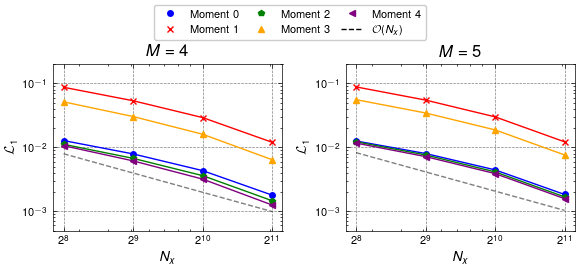

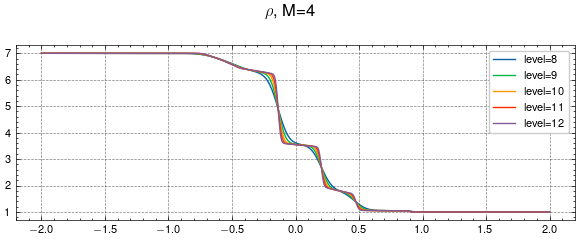

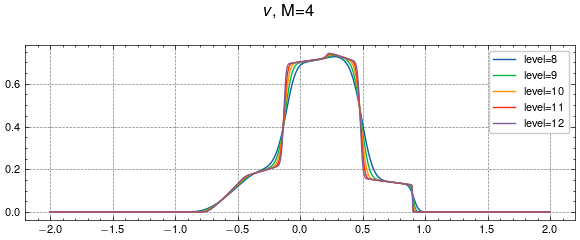

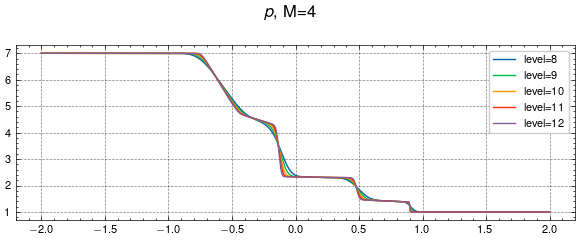

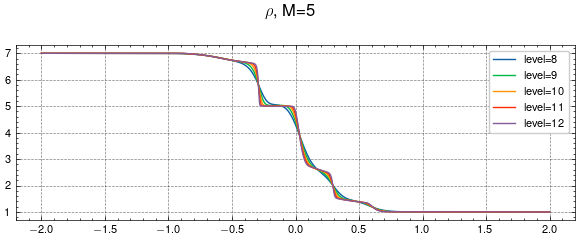

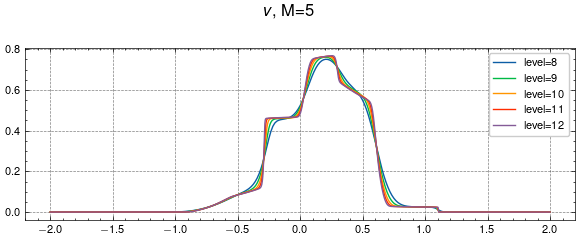

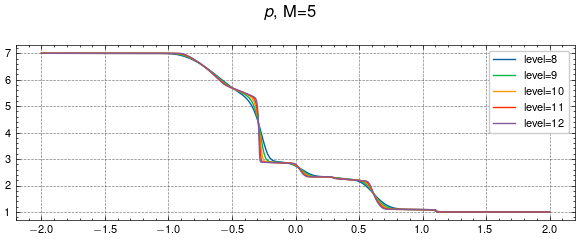

In [6]:
Moments = [4, 5]
base_tree_level_vec = [8, 9, 10, 11, 12] #![3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
source_string = 'relaxation_source'

fig, axs = plt.subplots(1, 2)

for i, M in enumerate(Moments):
    moment_solutions = []
    x_solutions = []
    fig_rho, axs_rho = plt.subplots()
    fig_v, axs_v = plt.subplots()
    fig_p, axs_p = plt.subplots()
    
    for base_tree_level in base_tree_level_vec:
        filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
        
        data = read_solution_file(filename)

        # Build time → timestep mapping
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))

        time_query = 21 # last time step
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, u, t = sol["x"], sol["u"], sol["t"]

        
        x_solutions.append(x)
        moment_solutions.append(u)  # Store all moments

        rho = u[:, 0]
        v = u[:, 1] / rho
        p = u[:, 2] - rho * v**2

        axs_rho.plot(x, rho, label=f'level={base_tree_level}')
        axs_v.plot(x, v, label=f'level={base_tree_level}')
        axs_p.plot(x, p, label=f'level={base_tree_level}')

    [ax.legend() for ax in [axs_rho, axs_v, axs_p]]
    [fig.suptitle(f'{title}, M={M}') for title, fig in zip(['$\\rho$', '$v$', '$p$'], [fig_rho, fig_v, fig_p])]
    [fig.tight_layout() for fig in [fig_rho, fig_v, fig_p]]
    [fig.show() for fig in [fig_rho, fig_v, fig_p]]

    errors = {}
    Nx = []
    for mom in range(M+1):
        errors[mom] = []
        ref_solution = interp1d(x_solutions[-1], moment_solutions[-1][:, mom])  # Using the same data as reference for simplicity
        for j, tree_level in enumerate(base_tree_level_vec[:-1]):
            data_trixi = moment_solutions[j][:, mom]
            trixi_solution = interp1d(x_solutions[j], data_trixi, kind='linear', fill_value="extrapolate") # ! cubic
            
            diff = ref_solution(x_solutions[-1]) - trixi_solution(x_solutions[-1])
            # error = np.sqrt(np.mean(diff**2)) / np.sqrt(np.mean(ref_solution(x_solutions[-1])**2))
            error = np.mean(np.abs(diff)) / np.mean(np.abs(ref_solution(x_solutions[-1])))
            errors[mom].append(error)
            if mom == 0:
                Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

    for mom in range(5):
        axs[i].loglog(Nx, errors[mom], marker=marker_legend[mom], color=colors[mom])

    # --- Add Reference Slopes ---
    # Calculate dummy lines based on the last data point of Moment 0
    Nx = np.array(Nx)
    ref_y = np.array(errors[0][-1])
    ref_x_last = Nx[-1]
    
    # Slope 1: O(N^-1)
    slope1 = (ref_y - 8e-4) / (Nx / ref_x_last)
    # slope1 = ref_y / (Nx / ref_x_last)
    axs[i].loglog(Nx, slope1, 'k--', alpha=0.5, label='$\mathcal{O}(N_x)$')
    
    # axs[i].set_xticks(Nx)
    # axs[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'$2^{{{int(np.log2(x))}}}$'))
    # ... inside your loop ...
    axs[i].set_xticks(Nx)
    axs[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'$2^{{{int(np.log2(x))}}}$'))
    axs[i].xaxis.set_minor_formatter(ticker.NullFormatter()) 
    axs[i].set_xlabel('$N_x$')
    axs[i].set_ylabel('$\\mathcal{L}_1$')
    axs[i].set_ylim(5e-4, 2e-1)
    axs[i].set_title(f'$M={M}$')

moment_elements = [Line2D([0], [0], color=colors[mom], marker=marker_legend[mom], label=f'Moment {mom}', linestyle='') for mom in range(5)]
moment_elements.append(Line2D([0], [0], color='k', linestyle='--', label='$\mathcal{O}(N_x)$'))
fig.legend(
    handles=moment_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.12), 
    ncol=3, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

fig.tight_layout()
fig.savefig(f'../out/Figures/Riemann1D/GridConvergence_M4M5.pdf', bbox_inches='tight')
fig.show()

In [7]:
Nx

array([ 256,  512, 1024, 2048])